## **ROUGE Score**

The **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)** score measures the **quality of generated text** by comparing it to a reference text. It is widely used for **summarization and text generation tasks**.

We primarily use:
- **ROUGE-N**: Measures **n-gram overlap** between the generated text and reference text.
- **ROUGE-L**: Measures **longest common subsequence (LCS) overlap**, capturing sentence fluency.

---

### **ROUGE-N**

ROUGE-N evaluates **n-gram recall** between the generated and reference text. It is computed as:
- **Precision**: Measures how many of the generated n-grams appear in the reference text.
  $$
  \text{Precision} = \frac{\text{Overlapping n-grams}}{\text{Total n-grams in generated text}}
  $$

- **Recall**: Measures how many n-grams from the reference text appear in the generated text.
  $$
  \text{Precision} = \frac{\text{Overlapping n-grams}}{\text{Total n-grams in reference text}}
  $$

- **F1-Score**: The harmonic mean of Precision and Recall.
  $$
  \text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
  $$
  
where:
- **Generated** = set of n-grams from the generated text.
- **References** = set of n-grams from the reference text.
- **Count(ngram)** = frequency of the n-gram appearing in the respective text.


### **ROUGE-L: Longest Common Subsequence (LCS)**
Unlike ROUGE-N, which focuses on n-grams, **ROUGE-L** measures **sentence-level similarity** using the longest common subsequence (LCS):

- **Precision**: Measures how much of the generated text is part of the longest common subsequence (LCS) with the reference text.
  $$
  \text{Precision}_{\text{ROUGE-L}} = \frac{LCS(Generated, Reference)}{\text{Length of Generated Text}}
  $$

- **Recall**: Measures how much of the reference text is covered by the longest common subsequence.
  $$
  \text{Recall}_{\text{ROUGE-L}} = \frac{LCS(Generated, Reference)}{\text{Length of Reference Text}}
  $$

- **F1-Score**: The harmonic mean of **ROUGE-L Precision** and **ROUGE-L Recall**.
  $$
  \text{F1}_{\text{ROUGE-L}} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
  $$

where:
- **LCS(Generated, Reference)** is the **longest sequence of words** appearing in both texts in order.
- ROUGE-L captures **sentence fluency** rather than just word overlap.



- Load models

In [36]:
import os
import json

RESULT_FILE = os.path.join('results', 'summary_123L.json')

# Open the result file in read mode
with open(RESULT_FILE, 'r') as f:
    results = json.load(f)

- List of models

In [37]:
all_models = [
 'qwen2.5:0.5b',
 'qwen2.5:1.5b',
 'deepseek-r1:1.5b',
 'qwen2.5-coder:1.5b',
 'qwen:1.8b',
 'gemma2:2b',
 'codegemma:2b',
 'llama3.2:3b',
 'qwen2.5:3b',
 'qwen:4b',
 'codellama:7b',
 'mistral:7b',
 'mistrallite:7b',
 'llama2:13b',
 'qwen2.5:14b',
 'codestral:22b',
]

- Convert JSON to dictionary

In [38]:
# convert results to dictionary
results_dict = dict()
for result in results:
    results_dict[result['model']] = result['scores']

In [39]:
results_dict['gemma2:2b']

{'rouge1': {'precision': 0.5680580653913988,
  'recall': 0.38086902174849463,
  'fmeasure': 0.44757429961189804},
 'rouge2': {'precision': 0.16855325291383422,
  'recall': 0.1121655378503077,
  'fmeasure': 0.13265788664243952},
 'rouge3': {'precision': 0.046742384236663416,
  'recall': 0.030459500735998433,
  'fmeasure': 0.036629195091551776},
 'rougeL': {'precision': 0.37227986827986825,
  'recall': 0.2479285674690389,
  'fmeasure': 0.29228540863085517}}

- Plot ROUGE scores

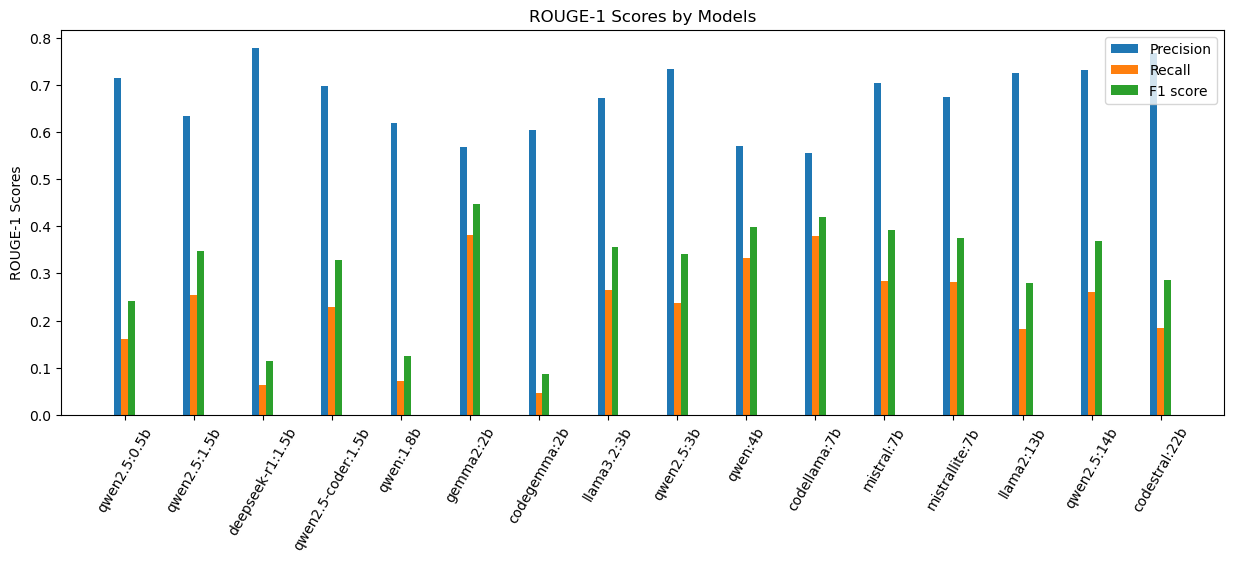

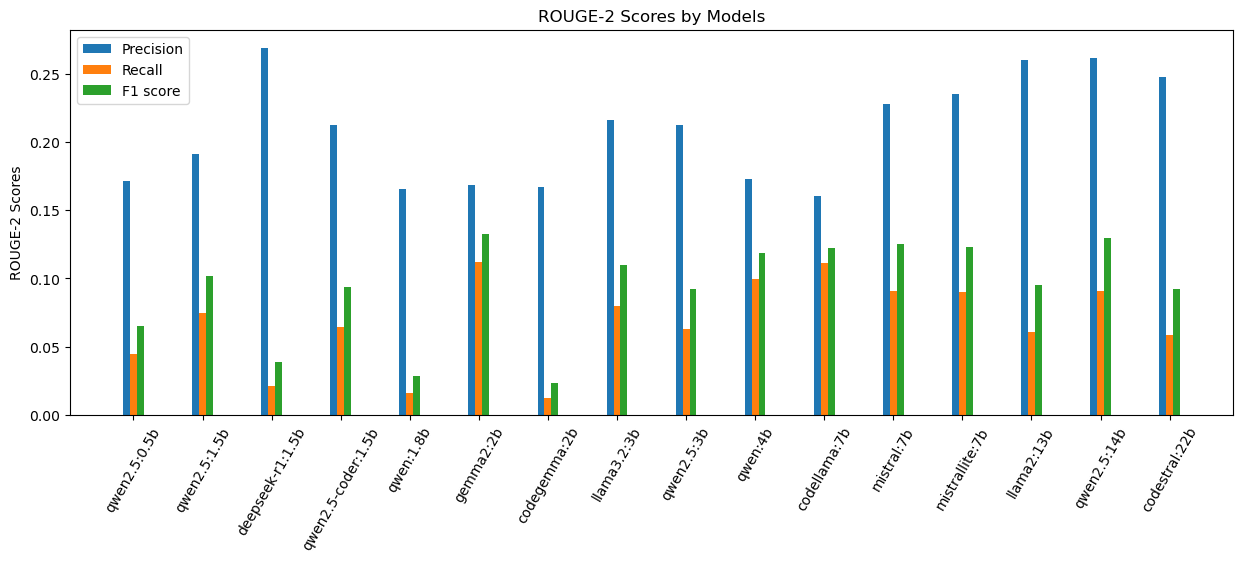

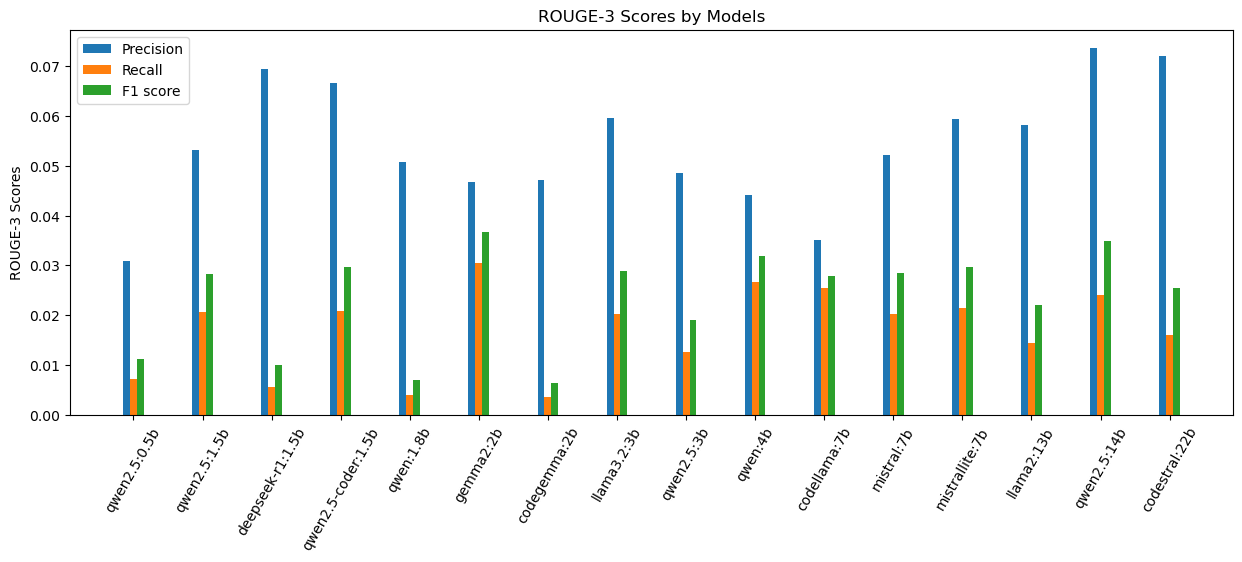

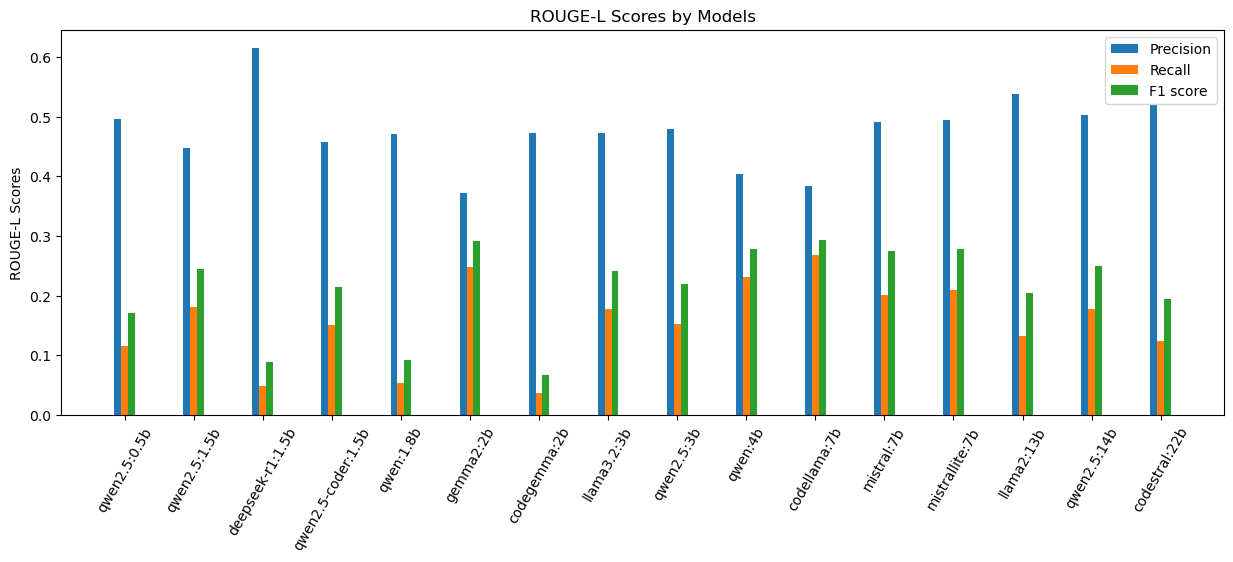

In [40]:
import matplotlib.pyplot as plt
import numpy as np

models = all_models

rouge1_precision = [results_dict[model]['rouge1']['precision'] for model in models]
rouge1_recall = [results_dict[model]['rouge1']['recall'] for model in models]
rouge1_fmeasure = [results_dict[model]['rouge1']['fmeasure'] for model in models]

rouge2_precision = [results_dict[model]['rouge2']['precision'] for model in models]
rouge2_recall = [results_dict[model]['rouge2']['recall'] for model in models]
rouge2_fmeasure = [results_dict[model]['rouge2']['fmeasure'] for model in models]

rouge3_precision = [results_dict[model]['rouge3']['precision'] for model in models]
rouge3_recall = [results_dict[model]['rouge3']['recall'] for model in models]
rouge3_fmeasure = [results_dict[model]['rouge3']['fmeasure'] for model in models]

rougel_precision = [results_dict[model]['rougeL']['precision'] for model in models]
rougel_recall = [results_dict[model]['rougeL']['recall'] for model in models]
rougel_fmeasure = [results_dict[model]['rougeL']['fmeasure'] for model in models]

fig, (ax0) = plt.subplots(1,1, figsize=(15,5))

x = np.arange(len(models))  # the label locations
width = 0.1  # the width of the bars

rects1 = ax0.bar(x - width*2, rouge1_precision, width, label='Precision')
rects2 = ax0.bar(x - width, rouge1_recall, width, label='Recall')
rects3 = ax0.bar(x, rouge1_fmeasure, width, label='F1 score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax0.set_ylabel('ROUGE-1 Scores')
ax0.set_title('ROUGE-1 Scores by Models')
ax0.set_xticks(x - width)
ax0.set_xticklabels(models, rotation=60)
ax0.legend()
plt.savefig('rouge_1.png', bbox_inches='tight')
plt.show()

fig, (ax1) = plt.subplots(1,1, figsize=(15,5))
rects1 = ax1.bar(x - width*2, rouge2_precision, width, label='Precision')
rects2 = ax1.bar(x - width, rouge2_recall, width, label='Recall')
rects3 = ax1.bar(x, rouge2_fmeasure, width, label='F1 score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax1.set_ylabel('ROUGE-2 Scores')
ax1.set_title('ROUGE-2 Scores by Models')
ax1.set_xticks(x - width)
ax1.set_xticklabels(models, rotation=60)
ax1.legend()
plt.savefig('rouge_2.png', bbox_inches='tight')
plt.show()

fig, (ax2) = plt.subplots(1,1, figsize=(15,5))
rects1 = ax2.bar(x - width*2, rouge3_precision, width, label='Precision')
rects2 = ax2.bar(x - width, rouge3_recall, width, label='Recall')
rects3 = ax2.bar(x, rouge3_fmeasure, width, label='F1 score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax2.set_ylabel('ROUGE-3 Scores')
ax2.set_title('ROUGE-3 Scores by Models')
ax2.set_xticks(x - width)
ax2.set_xticklabels(models, rotation=60)
ax2.legend()
plt.savefig('rouge_3.png', bbox_inches='tight')
plt.show()

fig, (ax3) = plt.subplots(1,1, figsize=(15,5))
rects1 = ax3.bar(x - width*2, rougel_precision, width, label='Precision')
rects2 = ax3.bar(x - width, rougel_recall, width, label='Recall')
rects3 = ax3.bar(x, rougel_fmeasure, width, label='F1 score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax3.set_ylabel('ROUGE-L Scores')
ax3.set_title('ROUGE-L Scores by Models')
ax3.set_xticks(x - width)
ax3.set_xticklabels(models, rotation=60)
ax3.legend()
plt.savefig('rouge_L.png', bbox_inches='tight')
plt.show()




# plt.subplots_adjust(hspace=0.4)
# plt.show()